# Data analysis notebook

## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ.setdefault('SIT_PSDM_DATA', '/home/groups/darve/hippowal/psdm')
os.environ.setdefault('SIT_ROOT', os.path.join(os.environ['SIT_PSDM_DATA'], 'sit_root'))
os.environ.setdefault('SIT_DATA', os.path.join(os.environ['SIT_PSDM_DATA'], 'data'))

'/home/groups/darve/hippowal/psdm/data'

In [2]:
from automask.shot_selection import Condition, ShotSelection

RUN = 389

# This field is the downstream sample diode for this experiment.
BRIGHTNESS_FIELD = 'diodeU/channels[0]'
all_valid_shots = ShotSelection(where=(
    Condition(BRIGHTNESS_FIELD, 'nonzero'),
))


## General statistics

[psana] opening 4 streams for run 389


2026-07-28 19:04:48.362 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:04:48.842 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:04:49.039 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:04:55.341 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


[scan] run 0389: 6471 shots read
run 0389: {'n_events': 6471, 'n_accessible': 6408, 'n_selected': 6408}


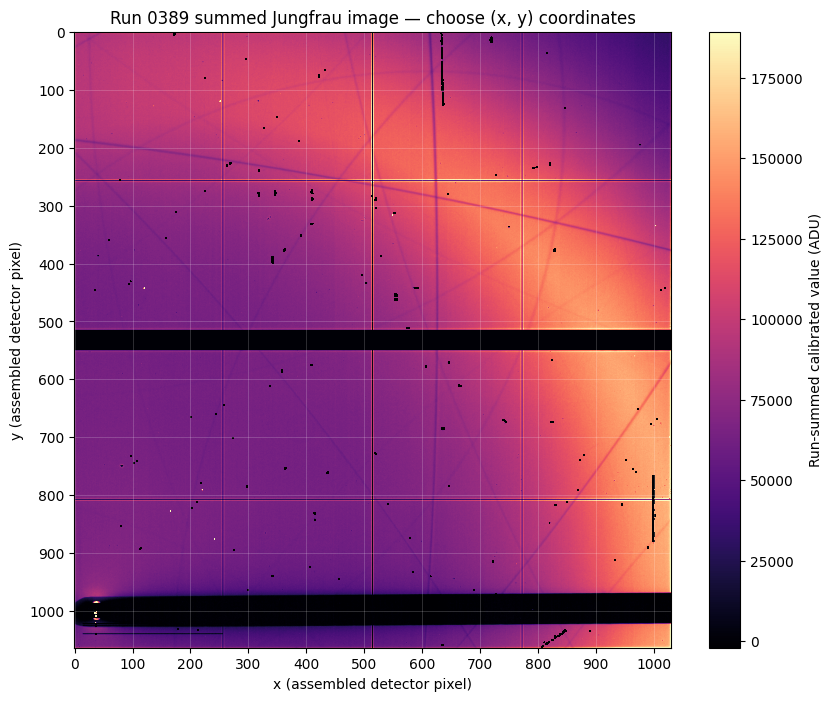

In [3]:
from automask.io.read_xtc import iter_calibrated, panel_geometry
from automask.utils import profile_run_values

run_profile = profile_run_values(RUN, show=False)
selected_indices = all_valid_shots.resolve(run_profile)
selection_counts = all_valid_shots.describe(run_profile)
print(f'run {RUN:04d}: {selection_counts}')

# Coordinates follow the assembled-array convention: a requested pixel is
# (x, y) = (first array axis, second array axis).  Transpose for display so
# these same coordinates appear as horizontal x and vertical y in the plot;
# origin='upper' keeps y increasing downward, like array indexing.
pixel_x, pixel_y = panel_geometry(RUN, source=run_profile.source)
sum_panel = np.zeros(pixel_x.shape, dtype=np.float64)
n_frames = 0
for _, frame in iter_calibrated(RUN, selected_indices, source=run_profile.source):
    sum_panel += frame
    n_frames += 1
sum_image = np.zeros((pixel_x.max() + 1, pixel_y.max() + 1), dtype=np.float64)
sum_image[pixel_x, pixel_y] = sum_panel
print(f'Summed {n_frames} selected calibrated frames')
display_sum_image = sum_image.T
detector_sum_values = sum_image[pixel_x, pixel_y]

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(
    display_sum_image, origin='upper', cmap='magma',
    vmin=np.nanpercentile(detector_sum_values, 1),
    vmax=np.nanpercentile(detector_sum_values, 99.5),
)
fig.colorbar(image, ax=ax, label='Run-summed calibrated value (ADU)')
ax.set_xlabel('x (assembled detector pixel)')
ax.set_ylabel('y (assembled detector pixel)')
ax.set_title(f'Run {RUN:04d} summed Jungfrau image — choose (x, y) coordinates')
ax.set_xticks(np.arange(0, display_sum_image.shape[1] + 1, 100))
ax.set_yticks(np.arange(0, display_sum_image.shape[0] + 1, 100))
ax.grid(color='white', alpha=0.25, linewidth=0.5)
plt.show()


[psana] opening 4 streams for run 389


2026-07-28 19:08:15.277 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:08:42.759 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:08:54.465 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:14:53.507 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


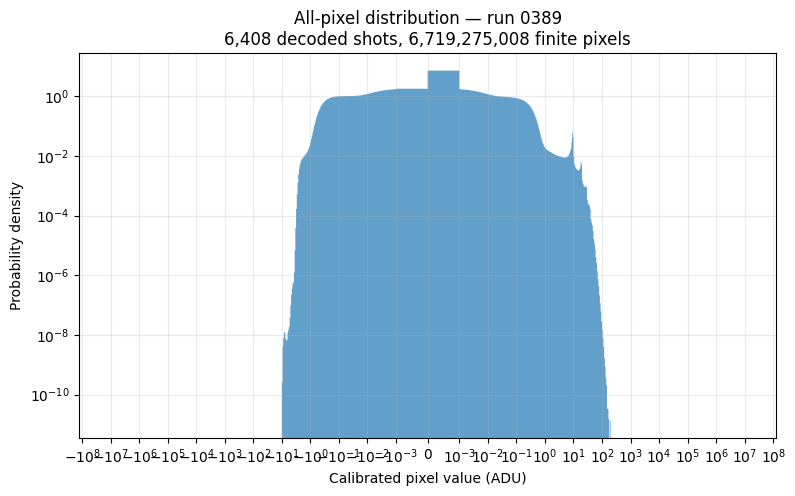

In [4]:
# Distribution over every finite detector pixel in every shot selected above.
# This streams frames rather than storing the full run in memory.
positive_edges = np.geomspace(1e-3, 1e7, 401)
bin_edges = np.r_[-positive_edges[::-1], 0.0, positive_edges]
counts = np.zeros(bin_edges.size - 1, dtype=np.int64)
n_frames = n_finite_pixels = n_outside_bins = 0

for event_index, frame in iter_calibrated(
    RUN, selected_indices, source=run_profile.source
):
    if all_valid_shots.normalization is not None:
        reference = all_valid_shots.normalization_reference(run_profile, selected_indices)
        i0 = run_profile.column(all_valid_shots.normalization)
        frame = frame * (reference / i0[event_index])
    values = frame[np.isfinite(frame)]
    counts += np.histogram(values, bins=bin_edges)[0]
    n_frames += 1
    n_finite_pixels += values.size
    n_outside_bins += np.count_nonzero((values < bin_edges[0]) | (values > bin_edges[-1]))

if n_frames == 0:
    raise RuntimeError(f'No calibrated frames were decoded for run {RUN}.')
if n_outside_bins:
    raise ValueError(f'{n_outside_bins:,} values fall outside the histogram range; increase the largest bin edge.')

density = counts / (n_finite_pixels * np.diff(bin_edges))
fig, ax = plt.subplots(figsize=(9, 5))
ax.stairs(density, bin_edges, fill=True, alpha=0.7, color='C0')
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_xlabel('Calibrated pixel value (ADU)')
ax.set_ylabel('Probability density')
ax.set_title(f'All-pixel distribution — run {RUN:04d}\n{n_frames:,} decoded shots, {n_finite_pixels:,} finite pixels')
ax.grid(True, which='both', alpha=0.25)
plt.show()


In [5]:
def _panel_location(x, y):
    """Map an assembled-image (x, y) coordinate to a Jungfrau panel index."""
    matches = np.flatnonzero((pixel_x == x) & (pixel_y == y))
    if matches.size != 1:
        raise ValueError(
            f'({x}, {y}) is not an active detector pixel. Choose a coordinate on a detector panel.'
        )
    return tuple(np.unravel_index(matches[0], pixel_x.shape))


def plot_distribution(pixels):
    """Plot selected-pixel distributions and mark their (x, y) positions in red.

    Parameters
    ----------
    pixels : list[tuple[int, int]]
        Assembled detector coordinates, for example [(520, 500), (740, 350)].
    """
    if not isinstance(pixels, list) or not pixels:
        raise TypeError('pixels must be a non-empty list of (x, y) tuples, e.g. [(520, 500)].')

    locations = {}
    for pixel in pixels:
        if not (isinstance(pixel, tuple) and len(pixel) == 2 and all(isinstance(v, (int, np.integer)) for v in pixel)):
            raise TypeError('Each item in pixels must be an integer (x, y) tuple.')
        x, y = map(int, pixel)
        if not (0 <= x < display_sum_image.shape[1] and 0 <= y < display_sum_image.shape[0]):
            raise ValueError(f'({x}, {y}) is outside the assembled image bounds.')
        locations[(x, y)] = _panel_location(x, y)

    samples = {pixel: [] for pixel in locations}
    normalize = all_valid_shots.normalization is not None
    reference = (
        all_valid_shots.normalization_reference(run_profile, selected_indices)
        if normalize else 1.0
    )
    i0 = run_profile.column(all_valid_shots.normalization) if normalize else None
    for event_index, frame in iter_calibrated(
        RUN, selected_indices, source=run_profile.source
    ):
        scale = reference / i0[event_index] if normalize else 1.0
        for pixel, location in locations.items():
            value = frame[location] * scale
            if np.isfinite(value):
                samples[pixel].append(value)

    fig, (ax_image, ax_hist) = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
    image = ax_image.imshow(
        display_sum_image, origin='upper', cmap='magma',
        vmin=np.nanpercentile(detector_sum_values, 1),
        vmax=np.nanpercentile(detector_sum_values, 99.5),
    )
    fig.colorbar(image, ax=ax_image, label='Run-summed calibrated value (ADU)')
    for x, y in locations:
        ax_image.scatter(x, y, s=70, c='red', edgecolors='white', linewidths=0.8, zorder=3)
        ax_image.annotate(f'({x}, {y})', (x, y), xytext=(5, 5), textcoords='offset points', color='white')
    ax_image.set(xlabel='x (assembled detector pixel)', ylabel='y (assembled detector pixel)', title='Selected pixels')
    ax_image.set_xticks(np.arange(0, display_sum_image.shape[1] + 1, 100))
    ax_image.set_yticks(np.arange(0, display_sum_image.shape[0] + 1, 100))
    ax_image.grid(color='white', alpha=0.25, linewidth=0.5)

    for pixel, values in samples.items():
        ax_hist.hist(values, bins='auto', density=True, histtype='step', linewidth=1.8, label=f'{pixel} (n={len(values):,})')
    ax_hist.set(xlabel='Calibrated pixel value (ADU)', ylabel='Probability density', title='Per-shot pixel-value distributions')
    ax_hist.grid(alpha=0.25)
    ax_hist.legend()
    plt.show()
    return {pixel: np.asarray(values) for pixel, values in samples.items()}

[psana] opening 4 streams for run 389


2026-07-28 19:16:36.042 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:16:49.912 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:16:55.828 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:19:58.865 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


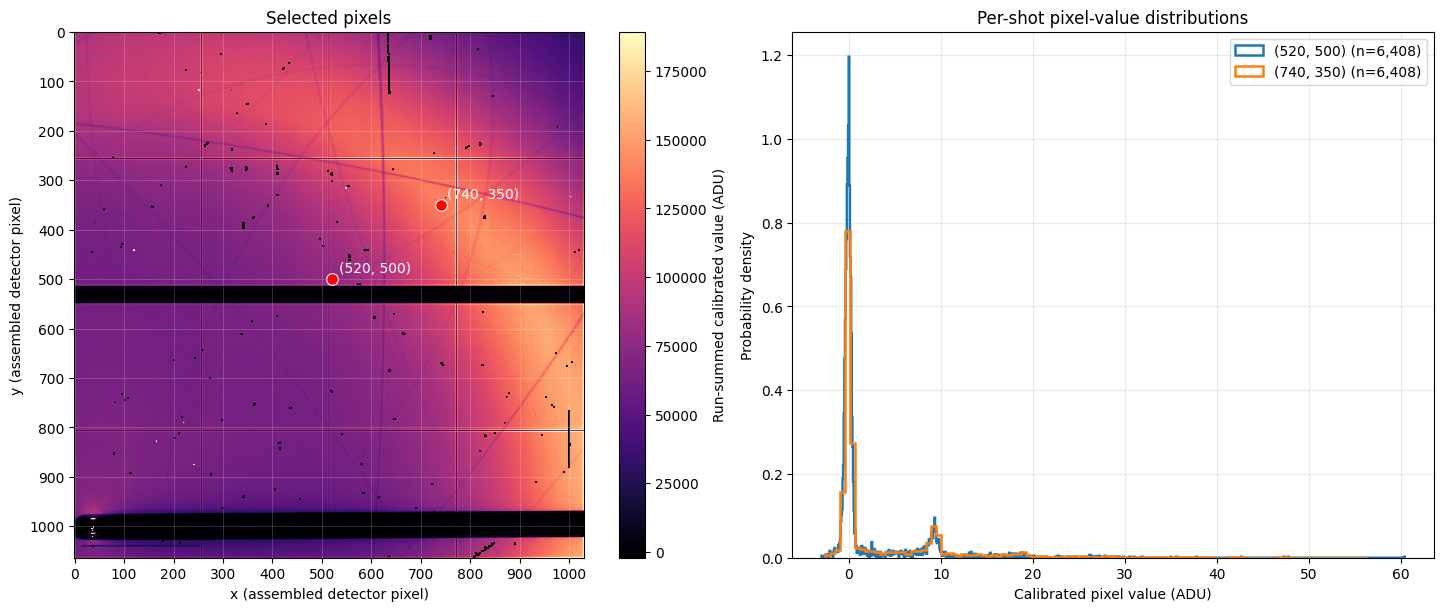

In [6]:
# Example (replace these with coordinates chosen from the image above):
pixel_values = plot_distribution([(520, 500), (740, 350)])

[psana] opening 4 streams for run 389


2026-07-28 19:21:39.037 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:21:52.934 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:21:58.891 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:25:00.873 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


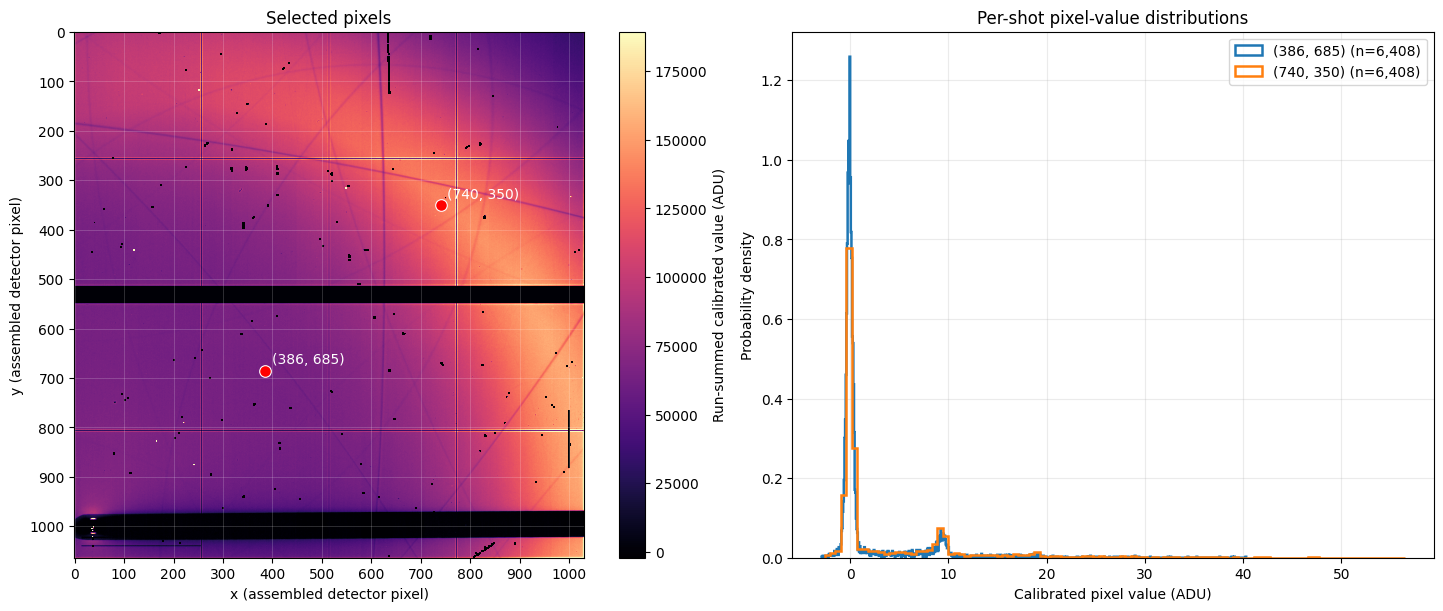

In [7]:
pixel_values = plot_distribution([(386, 685), (740, 350)])

[psana] opening 4 streams for run 389


2026-07-28 19:26:40.905 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:26:54.808 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:27:00.748 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:30:02.146 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


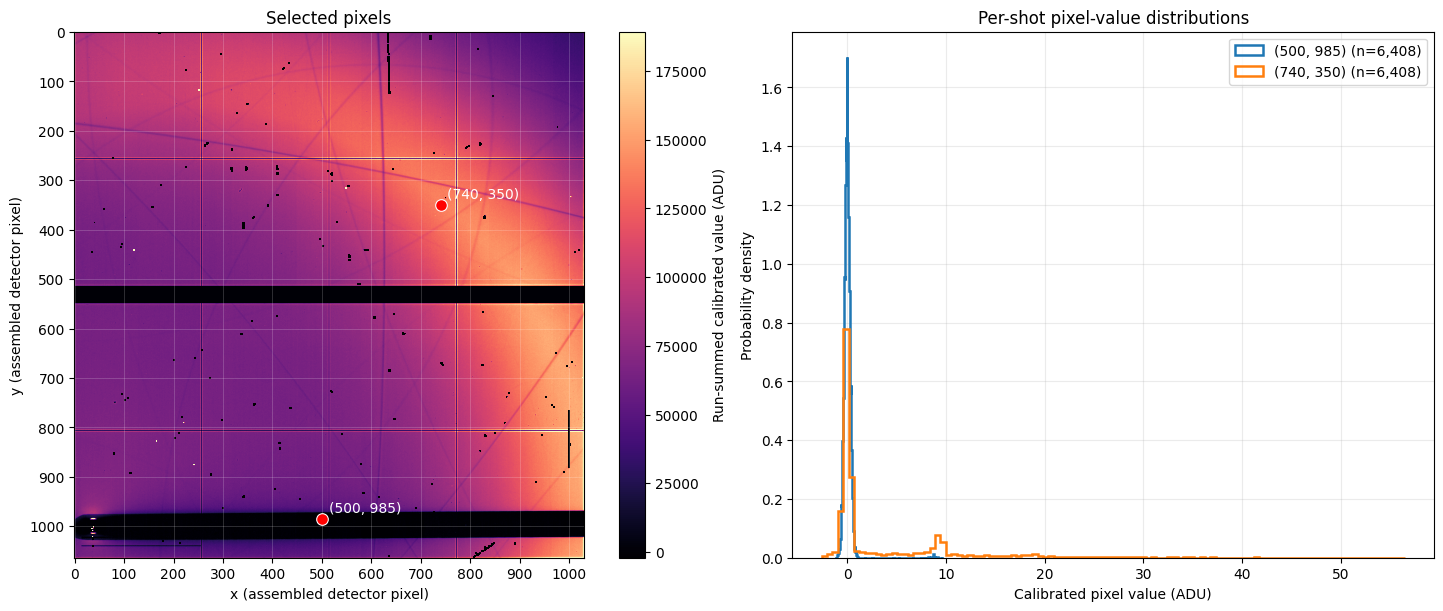

In [8]:
pixel_values = plot_distribution([(500, 985), (740, 350)])

[psana] opening 4 streams for run 389


2026-07-28 19:30:31.638 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s04-c00.xtc
2026-07-28 19:30:35.762 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s01-c00.xtc
2026-07-28 19:30:37.609 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc
2026-07-28 19:31:23.307 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s00-c00.xtc


Selected / decoded bright shots: {2: (129, 129), 5: (321, 321), 10: (641, 641), 25: (1602, 1602)}


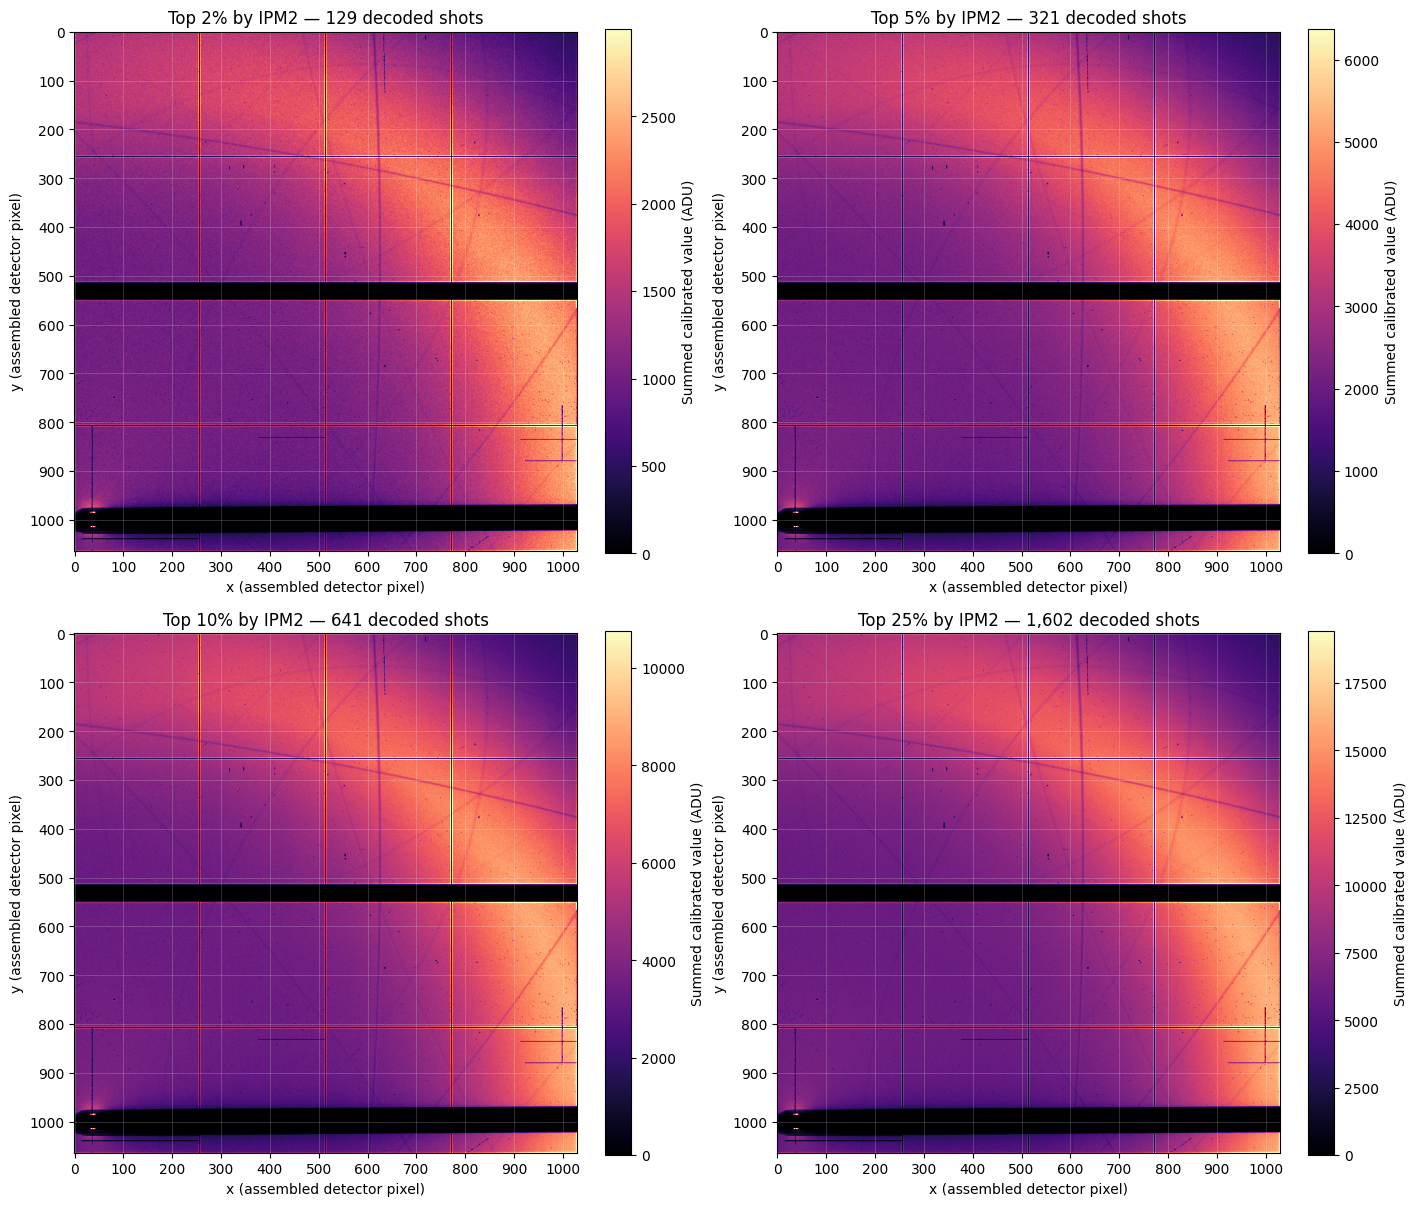

In [9]:
BRIGHT_FRACTIONS = (2, 5, 10, 25)  # percentages of the active ShotSelection

# Rank only the shots already admitted by `all_valid_shots`, using the
# practitioner-specified downstream brightness field. Do NOT rank on
# ipm2: it sits upstream of the CC/VCC beam split, so it cannot see the flux
# change that actually reaches the detector (see DATA.md). The largest subset
# contains all others, so one XTC pass is sufficient for all four sums.
brightness = run_profile.column(BRIGHTNESS_FIELD)
ranked_indices = selected_indices[np.argsort(brightness[selected_indices])[::-1]]
bright_indices = {
    percent: ranked_indices[:max(1, int(np.ceil(percent / 100 * ranked_indices.size)))]
    for percent in BRIGHT_FRACTIONS
}
bright_members = {percent: set(indices.tolist()) for percent, indices in bright_indices.items()}
largest_subset = bright_indices[max(BRIGHT_FRACTIONS)]

bright_event_sums_panel = {percent: np.zeros(pixel_x.shape, dtype=np.float64) for percent in BRIGHT_FRACTIONS}
bright_event_counts = {percent: 0 for percent in BRIGHT_FRACTIONS}
normalize = all_valid_shots.normalization is not None
reference = (
    all_valid_shots.normalization_reference(run_profile, selected_indices)
    if normalize else 1.0
)
i0 = run_profile.column(all_valid_shots.normalization) if normalize else None

for event_index, frame in iter_calibrated(
    RUN, largest_subset, source=run_profile.source
):
    scale = reference / i0[event_index] if normalize else 1.0
    for percent in BRIGHT_FRACTIONS:
        if event_index in bright_members[percent]:
            bright_event_sums_panel[percent] += frame * scale
            bright_event_counts[percent] += 1

# Assemble and transpose each sum to use the same (x, y) display convention.
bright_event_sums = {}
for percent, panel_sum in bright_event_sums_panel.items():
    assembled_sum = np.zeros_like(sum_image)
    assembled_sum[pixel_x, pixel_y] = panel_sum
    bright_event_sums[percent] = assembled_sum.T

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
for ax, percent in zip(axes.flat, BRIGHT_FRACTIONS):
    image_sum = bright_event_sums[percent]
    detector_values = image_sum[display_sum_image != 0]
    image = ax.imshow(
        image_sum, origin='upper', cmap='magma',
        vmin=np.nanpercentile(detector_values, 1),
        vmax=np.nanpercentile(detector_values, 99.5),
    )
    fig.colorbar(image, ax=ax, label='Summed calibrated value (ADU)')
    ax.set_title(f'Top {percent}% by {BRIGHTNESS_FIELD} — {bright_event_counts[percent]:,} decoded shots')
    ax.set_xlabel('x (assembled detector pixel)')
    ax.set_ylabel('y (assembled detector pixel)')
    ax.set_xticks(np.arange(0, image_sum.shape[1] + 1, 100))
    ax.set_yticks(np.arange(0, image_sum.shape[0] + 1, 100))
    ax.grid(color='white', alpha=0.25, linewidth=0.5)

print('Selected / decoded bright shots:', {p: (bright_indices[p].size, bright_event_counts[p]) for p in BRIGHT_FRACTIONS})
